# Edge Validation and Return Decomposition — Section 8.3

Why does the small log-loss gap between Elo and the full model produce a much larger trading
difference under half-Kelly compounding? This notebook validates the model edge by bucket and
decomposes returns across (both / FM-only / Elo-only) trade partitions.

**Outputs:**

| File | Purpose |
|---|---|
| `trade_hit_rate_by_edge_bucket.png` | Hit rate by model-implied edge bucket |
| `trade_return_decomposition_table.csv` | Return decomposition by partition |
| `trade_pnl_by_trade_partition.png` | P&L contribution by partition |
| `trade_returns_by_edge_bucket_table.csv` | Appendix — exact numbers |
| `trade_returns_by_entry_price_bucket.csv` | Appendix — by entry price |
| `trade_characteristic_correlation_heatmap.png` | Appendix correlation heatmap |

In [1]:
import sys, warnings
warnings.filterwarnings('ignore')
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams.update({'font.size': 11, 'axes.titlesize': 13, 'figure.dpi': 120})

ANALYSIS_DIR = Path('../..').resolve() / 'src' / 'srwnba' / 'analysis'
if str(ANALYSIS_DIR) not in sys.path:
    sys.path.insert(0, str(ANALYSIS_DIR))

from outputs import save_fig, save_table
from walkforward import fit_holdout_models
from markets import build_kalshi_trading_index
from trading import (
    collect_entries, run_fixed_risk, run_kelly_ideal, add_trade_returns,
    BANKROLL_INIT,
)
from final_model import load_year, LABEL_COL  # type: ignore

MODEL_LABELS = {'elo': 'Elo', 'full_model': 'Full Model'}
MODEL_COLORS = {'elo': '#3498db', 'full_model': '#e74c3c'}

In [2]:
# Setup: predictions, trading index, both models' best half-Kelly trades
preds_df, _ = fit_holdout_models(
    {'xgb_with_elo': {'type': 'xgb', 'use_bm': True}, 'elo': {'type': 'elo'}},
    holdout_year=2025,
)
model_w = preds_df[preds_df['model'] == 'xgb_with_elo'][['game_id','pred_prob']].rename(columns={'pred_prob':'p_full_model'})
elo_w   = preds_df[preds_df['model'] == 'elo'][['game_id','pred_prob']].rename(columns={'pred_prob':'p_elo'})
test_df = load_year(2025).dropna(subset=[LABEL_COL, 'base_margin'])[
    ['game_id','game_ts','game_date','home_team_id','away_team_id', LABEL_COL]
].copy()
test_df['game_ts']   = pd.to_datetime(test_df['game_ts'], utc=True)
test_df['game_date'] = pd.to_datetime(test_df['game_date'])
signals = test_df.merge(model_w, on='game_id').merge(elo_w, on='game_id')

idx = build_kalshi_trading_index(signals)
ticker_info, pretip = idx['ticker_info'], idx['pretip']
game_dt_map = signals.set_index('game_id')['game_date'].to_dict()

# Use a shared best half-Kelly config so the partition comparison is apples-to-apples
BEST_EDGE_MIN = 0.05
BEST_NORM_MIN = 0.25

entries_fm  = collect_entries(ticker_info, pretip, 'p_full_model', BEST_EDGE_MIN, BEST_NORM_MIN, 'half_life')
entries_elo = collect_entries(ticker_info, pretip, 'p_elo',         BEST_EDGE_MIN, BEST_NORM_MIN, 'half_life')
tdf_fm  = add_trade_returns(pd.DataFrame(run_kelly_ideal(entries_fm,  0.5, BANKROLL_INIT)))
tdf_elo = add_trade_returns(pd.DataFrame(run_kelly_ideal(entries_elo, 0.5, BANKROLL_INIT)))
for tdf in (tdf_fm, tdf_elo):
    tdf['game_date'] = pd.to_datetime(tdf['game_id'].map(game_dt_map))

print(f'Full model: {len(tdf_fm)} trades, hit {tdf_fm["won"].mean():.1%}, terminal ${tdf_fm["bankroll"].iloc[-1]:,.0f}')
print(f'Elo:        {len(tdf_elo)} trades, hit {tdf_elo["won"].mean():.1%}, terminal ${tdf_elo["bankroll"].iloc[-1]:,.0f}')

  xgb_with_elo             best_round=88
Full model: 134 trades, hit 40.3%, terminal $1,162
Elo:        155 trades, hit 34.2%, terminal $517


---
## §8.3.1 — Hit rate by edge bucket
**Figure:** `trade_hit_rate_by_edge_bucket`. Built from a wider entry filter (edge≥0.05, no
norm_edge gate) under fixed-$1 sizing, so we get enough trades to bucket cleanly.

  saved: outputs\trade_hit_rate_by_edge_bucket.png


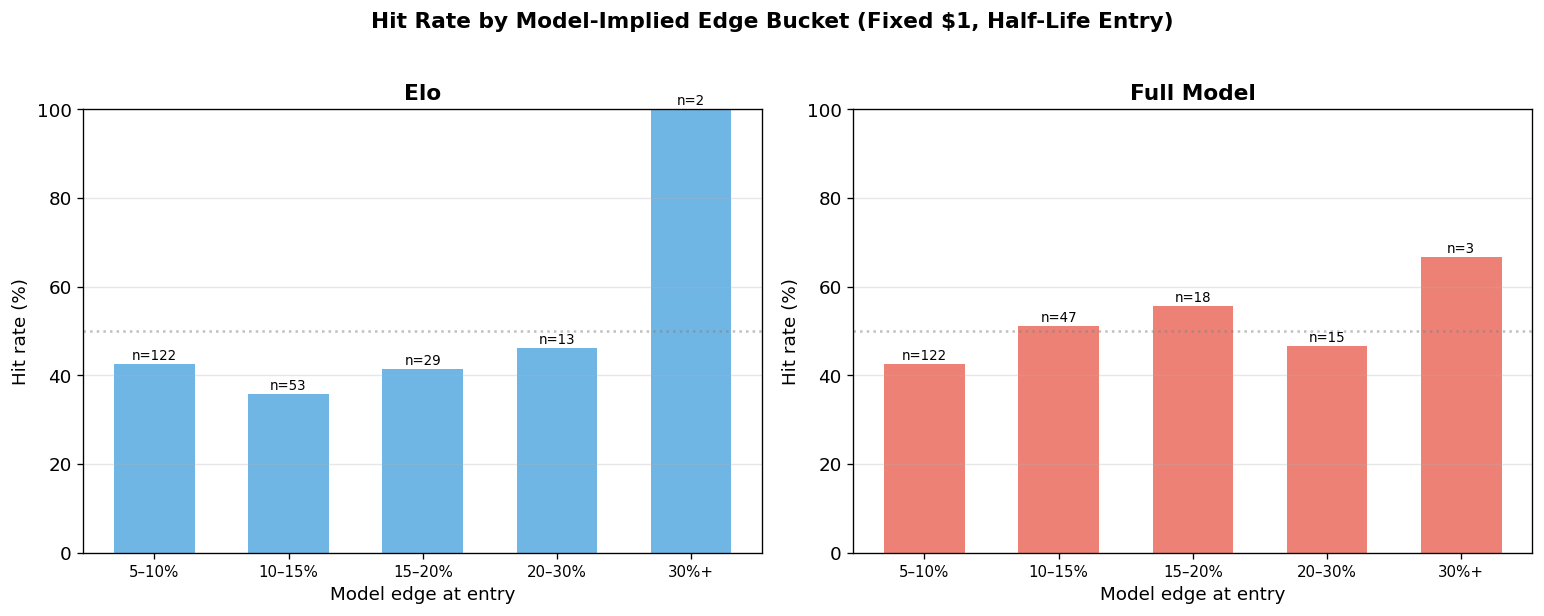

  saved: outputs\trade_returns_by_edge_bucket_table.csv


,edge_bucket,n,hit_rate,mean_pnl,total_pnl,model
0,5–10%,122,0.426230,0.084917,10.359908,elo
1,10–15%,53,0.358491,-0.082461,-4.370447,elo
2,15–20%,29,0.413793,0.402227,11.664574,elo
3,20–30%,13,0.461538,0.597308,7.765008,elo
4,30%+,2,1.000000,2.692690,5.385380,elo
5,5–10%,122,0.426230,-0.007259,-0.885549,full_model
6,10–15%,47,0.510638,0.258759,12.161692,full_model
7,15–20%,18,0.555556,0.248980,4.481636,full_model
8,20–30%,15,0.466667,0.547137,8.207057,full_model
9,30%+,3,0.666667,1.445127,4.335380,full_model


In [3]:
EDGE_BIN_EDGES  = [0, 0.05, 0.10, 0.15, 0.20, 0.30, 1.0]
EDGE_BIN_LABELS = ['0–5%', '5–10%', '10–15%', '15–20%', '20–30%', '30%+']

def trades_for_buckets(model_col):
    ents = collect_entries(ticker_info, pretip, model_col, 0.05, 0.0, 'half_life')
    return pd.DataFrame(run_fixed_risk(ents, risk_per_trade=1.0, bankroll_init=BANKROLL_INIT))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
bucket_rows = []
for ax, (model_name, model_col) in zip(axes, [('elo', 'p_elo'), ('full_model', 'p_full_model')]):
    bdf = trades_for_buckets(model_col)
    if bdf.empty:
        continue
    bdf['edge_bucket'] = pd.cut(bdf['edge'], bins=EDGE_BIN_EDGES, labels=EDGE_BIN_LABELS)
    stats = bdf.groupby('edge_bucket', observed=True).agg(
        n=('pnl','count'), hit_rate=('won','mean'),
        mean_pnl=('pnl','mean'), total_pnl=('pnl','sum'),
    ).reset_index()
    stats['model'] = model_name
    bucket_rows.append(stats)

    color = MODEL_COLORS[model_name]
    bars = ax.bar(range(len(stats)), stats['hit_rate'] * 100, color=color, alpha=0.7, width=0.6)
    for x, bar, n in zip(range(len(stats)), bars, stats['n']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'n={int(n)}', ha='center', fontsize=8)
    ax.set_xticks(range(len(stats)))
    ax.set_xticklabels(stats['edge_bucket'].astype(str), fontsize=9)
    ax.set_xlabel('Model edge at entry')
    ax.set_ylabel('Hit rate (%)')
    ax.set_title(MODEL_LABELS[model_name], fontweight='bold')
    ax.axhline(50, color='gray', linestyle=':', alpha=0.5)
    ax.set_ylim(0, 100); ax.grid(axis='y', alpha=0.3)

plt.suptitle('Hit Rate by Model-Implied Edge Bucket (Fixed $1, Half-Life Entry)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
save_fig(fig, 'trade_hit_rate_by_edge_bucket')
plt.show()

edge_bucket_tbl = pd.concat(bucket_rows, ignore_index=True)
save_table(edge_bucket_tbl, 'trade_returns_by_edge_bucket_table')
edge_bucket_tbl

---
## §8.3.2 — Return decomposition by trade partition
Splits trades into three partitions:
  - **Shared** — game traded by both models
  - **FM only** — game only the full model traded
  - **Elo only** — game only Elo traded

**Table:** `trade_return_decomposition_table`. **Figure:** `trade_pnl_by_trade_partition`.

In [4]:
games_fm  = set(tdf_fm['game_id'])
games_elo = set(tdf_elo['game_id'])
shared    = games_fm & games_elo
only_fm   = games_fm - games_elo
only_elo  = games_elo - games_fm

def partition_stats(tdf, ids, label, model_name):
    sub = tdf[tdf['game_id'].isin(ids)]
    return {
        'partition': label, 'model': model_name,
        'n_trades':   len(sub),
        'hit_rate':   float(sub['won'].mean())   if len(sub) else float('nan'),
        'total_pnl':  float(sub['pnl'].sum()),
        'mean_pnl':   float(sub['pnl'].mean())   if len(sub) else float('nan'),
        'mean_kelly_f': float(sub['kelly_f'].mean()) if len(sub) else float('nan'),
        'mean_edge':   float(sub['edge'].mean())  if len(sub) else float('nan'),
        'mean_log_ret': float(sub['log_ret'].mean()) if len(sub) else float('nan'),
    }

decomp = pd.DataFrame([
    partition_stats(tdf_fm,  shared,    'shared',   'full_model'),
    partition_stats(tdf_elo, shared,    'shared',   'elo'),
    partition_stats(tdf_fm,  only_fm,   'fm_only',  'full_model'),
    partition_stats(tdf_elo, only_elo,  'elo_only', 'elo'),
])
save_table(decomp, 'trade_return_decomposition_table')
decomp

  saved: outputs\trade_return_decomposition_table.csv


,partition,model,n_trades,hit_rate,total_pnl,mean_pnl,mean_kelly_f,mean_edge,mean_log_ret
0,shared,full_model,111,0.351351,-1.241253,-0.011182,0.211239,0.136140,0.012003
1,shared,elo,111,0.351351,209.529587,1.887654,0.216299,0.143459,0.010865
2,fm_only,full_model,23,0.652174,1063.027045,46.218567,0.248249,0.122764,0.048707
3,elo_only,elo,44,0.318182,207.442598,4.714604,0.120169,0.086527,0.009927


  saved: outputs\trade_pnl_by_trade_partition.png


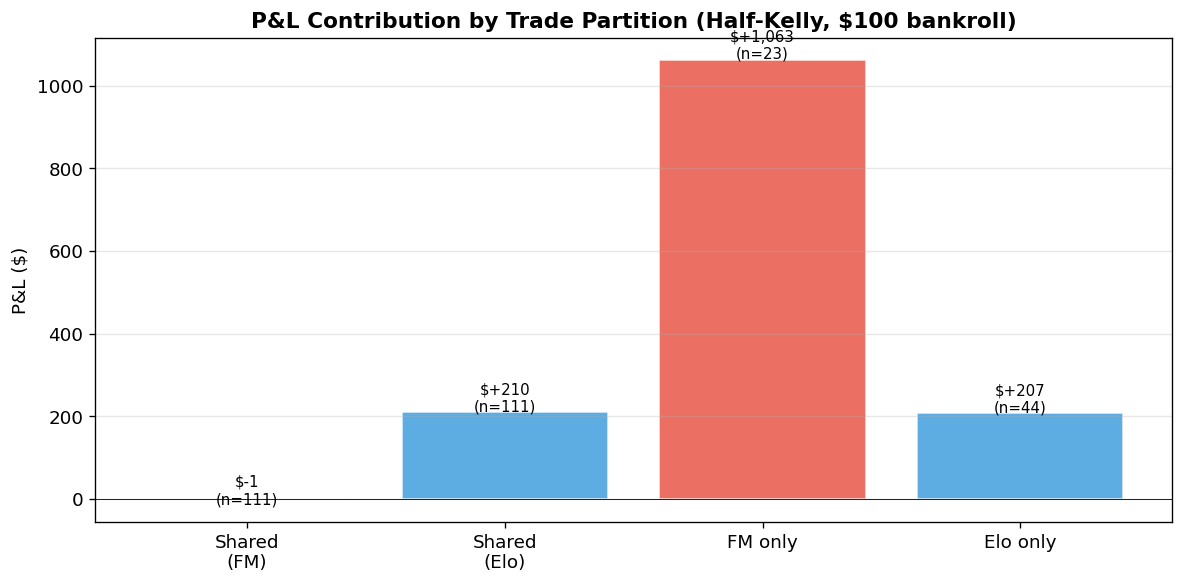

In [5]:
# Bar chart of P&L by partition
fig, ax = plt.subplots(figsize=(10, 5))
labels = ['Shared\n(FM)', 'Shared\n(Elo)', 'FM only', 'Elo only']
vals = [
    decomp.query('partition=="shared"  & model=="full_model"')['total_pnl'].iloc[0],
    decomp.query('partition=="shared"  & model=="elo"'       )['total_pnl'].iloc[0],
    decomp.query('partition=="fm_only" & model=="full_model"')['total_pnl'].iloc[0],
    decomp.query('partition=="elo_only"& model=="elo"'       )['total_pnl'].iloc[0],
]
ns = [
    decomp.query('partition=="shared"  & model=="full_model"')['n_trades'].iloc[0],
    decomp.query('partition=="shared"  & model=="elo"'       )['n_trades'].iloc[0],
    decomp.query('partition=="fm_only" & model=="full_model"')['n_trades'].iloc[0],
    decomp.query('partition=="elo_only"& model=="elo"'       )['n_trades'].iloc[0],
]
colors = [MODEL_COLORS['full_model'], MODEL_COLORS['elo'],
          MODEL_COLORS['full_model'], MODEL_COLORS['elo']]
bars = ax.bar(range(len(labels)), vals, color=colors, alpha=0.8, edgecolor='white')
for x, bar, val, n in zip(range(len(labels)), bars, vals, ns):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + (3 if h >= 0 else -10),
            f'${val:+,.0f}\n(n={int(n)})', ha='center', fontsize=9)
ax.axhline(0, color='black', linewidth=0.5)
ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels)
ax.set_ylabel('P&L ($)')
ax.set_title('P&L Contribution by Trade Partition (Half-Kelly, $100 bankroll)', fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
save_fig(fig, 'trade_pnl_by_trade_partition')
plt.show()

---
## §8.3 Appendix

In [6]:
# Returns by entry price bucket
PX_BIN_EDGES  = [0, 0.20, 0.35, 0.50, 0.65, 0.80, 1.0]
PX_BIN_LABELS = ['0–20%', '20–35%', '35–50%', '50–65%', '65–80%', '80%+']
rows = []
for model_name, tdf in [('full_model', tdf_fm), ('elo', tdf_elo)]:
    sub = tdf.copy()
    sub['px_bucket'] = pd.cut(sub['entry_px'], bins=PX_BIN_EDGES, labels=PX_BIN_LABELS)
    stats = sub.groupby('px_bucket', observed=True).agg(
        n=('pnl','count'), hit_rate=('won','mean'),
        mean_pnl=('pnl','mean'), total_pnl=('pnl','sum'),
        mean_log_ret=('log_ret','mean'),
    ).reset_index()
    stats['model'] = model_name
    rows.append(stats)
px_bucket_tbl = pd.concat(rows, ignore_index=True)
save_table(px_bucket_tbl, 'trade_returns_by_entry_price_bucket')
px_bucket_tbl

  saved: outputs\trade_returns_by_entry_price_bucket.csv


,px_bucket,n,hit_rate,mean_pnl,total_pnl,mean_log_ret,model
0,0–20%,35,0.171429,-11.661756,-408.161445,0.020126,full_model
1,20–35%,46,0.347826,-16.758762,-770.903063,0.018012,full_model
2,35–50%,38,0.552632,42.532869,1616.249030,0.011986,full_model
3,50–65%,12,0.750000,70.836813,850.041761,0.051369,full_model
4,65–80%,3,0.666667,-75.146830,-225.440491,-0.050784,full_model
5,0–20%,50,0.180000,-9.462638,-473.131911,0.016573,elo
6,20–35%,62,0.354839,11.917755,738.900837,0.013692,elo
7,35–50%,36,0.500000,5.195249,187.028963,0.004687,elo
8,50–65%,6,0.666667,25.906928,155.441566,0.019190,elo
9,65–80%,1,0.000000,-191.267271,-191.267271,-0.318600,elo


  saved: outputs\trade_characteristic_correlation_heatmap.png


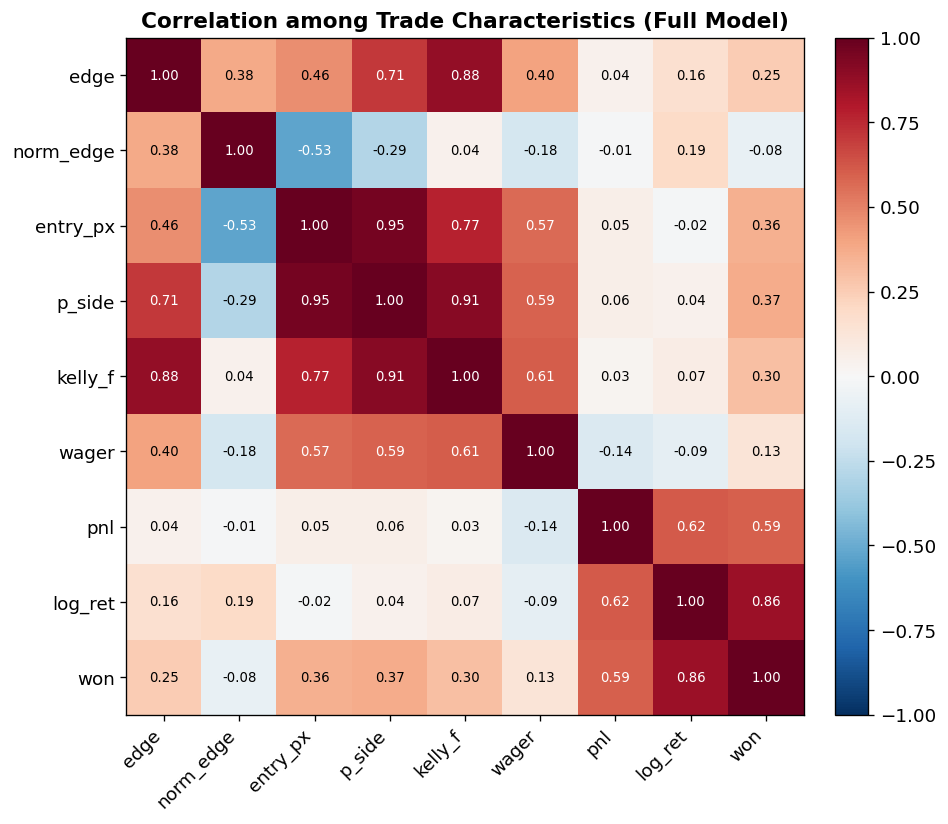

In [7]:
# Trade-characteristic correlation heatmap (full model)
corr_cols = ['edge', 'norm_edge', 'entry_px', 'p_side', 'kelly_f', 'wager',
             'pnl', 'log_ret', 'won']
corr = tdf_fm[corr_cols].corr()

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_cols))); ax.set_xticklabels(corr_cols, rotation=45, ha='right')
ax.set_yticks(range(len(corr_cols))); ax.set_yticklabels(corr_cols)
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center',
                fontsize=8, color='black' if abs(corr.iloc[i, j]) < 0.5 else 'white')
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_title('Correlation among Trade Characteristics (Full Model)', fontweight='bold')
plt.tight_layout()
save_fig(fig, 'trade_characteristic_correlation_heatmap')
plt.show()